In [2]:
#1.环境配置与库导入
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 检查GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.7.0+cpu


In [6]:
#2.数据预处理与加载

# 数据增强与归一化
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 加载数据集
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# 划分验证集（从训练集中分出5000张）
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f"训练集样本数: {len(train_dataset)}")
print(f"验证集样本数: {len(val_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")

100%|██████████| 170M/170M [3:21:19<00:00, 14.1kB/s]   


训练集样本数: 45000
验证集样本数: 5000
测试集样本数: 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.6232319].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.6524973].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.3793533].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.6607274].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..0.6908736].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.

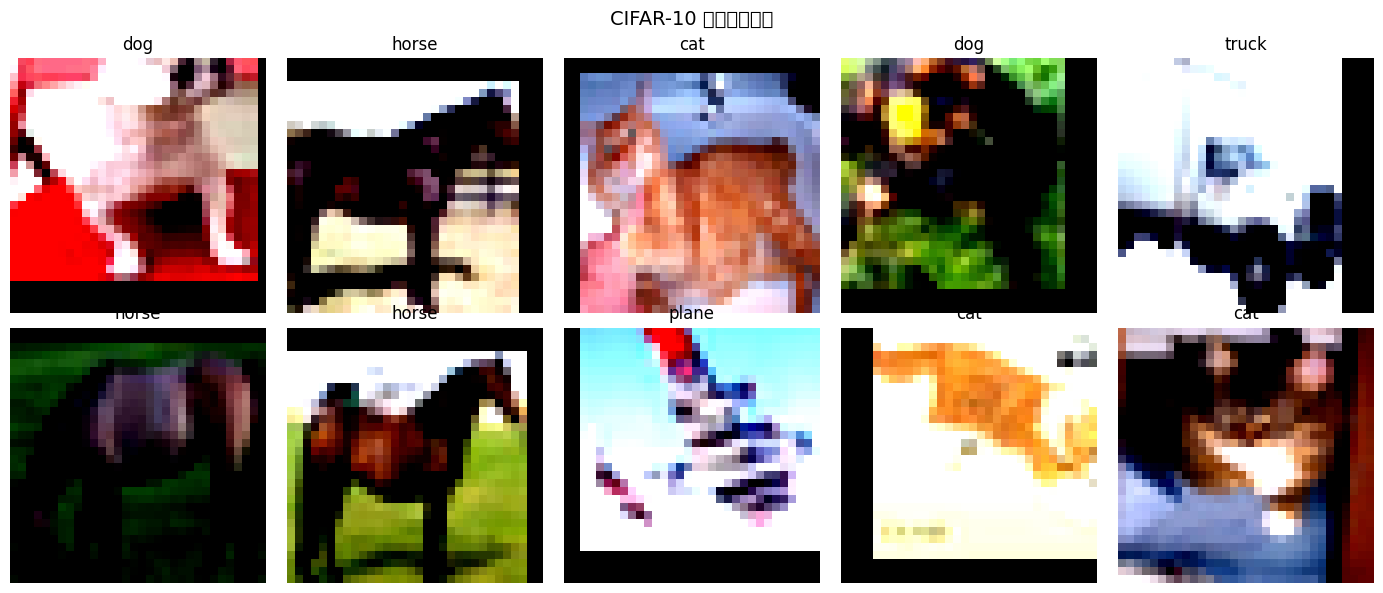

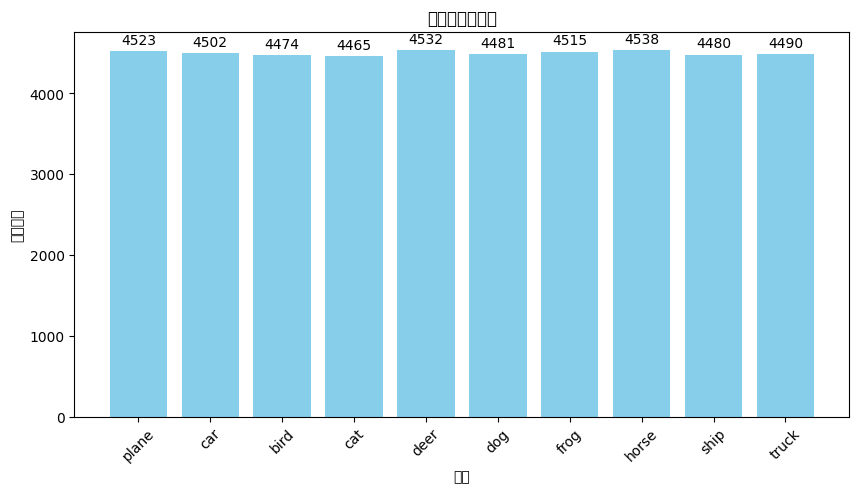

In [7]:
#3.数据可视化

# 显示样本图像
def imshow(img):
    img = img / 2 + 0.5  # 反归一化
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# 获取一批数据
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    imshow(images[i])
    plt.title(classes[labels[i]])
plt.suptitle('CIFAR-10 训练样本示例', fontsize=14)
plt.tight_layout()
plt.show()

# 类别分布统计
label_counts = [0] * 10
for _, labels in train_loader:
    for l in labels:
        label_counts[l] += 1

plt.figure(figsize=(10, 5))
plt.bar(classes, label_counts, color='skyblue')
plt.xlabel('类别')
plt.ylabel('样本数量')
plt.title('训练集类别分布')
plt.xticks(rotation=45)
for i, v in enumerate(label_counts):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')
plt.show()

In [8]:
#4.模型定义

# ========== Baseline: SimpleCNN ==========
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ========== Final Model: ResNet18 (CIFAR适配版) ==========
from torchvision.models import resnet18

class ResNet18CIFAR(nn.Module):
    def __init__(self):
        super(ResNet18CIFAR, self).__init__()
        self.model = resnet18(pretrained=False)
        # 适配CIFAR-10: 修改第一层卷积
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()  # 去掉初始maxpool
        self.model.fc = nn.Linear(512, 10)

    def forward(self, x):
        return self.model(x)

In [9]:
#5.训练函数

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, model_name="Model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    
    print(f"\n{'='*50}")
    print(f"训练 {model_name}")
    print(f"{'='*50}")
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        scheduler.step()
        print(f'Epoch [{epoch+1:2d}/{epochs}] Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')
    
    print(f"最佳验证准确率: {best_val_acc:.2f}%")
    return train_losses, val_losses, train_accs, val_accs, best_val_acc

In [10]:
#6.训练实验

# 训练Baseline模型
baseline_train_loss, baseline_val_loss, baseline_train_acc, baseline_val_acc, baseline_best = train_model(
    SimpleCNN(), train_loader, val_loader, epochs=20, lr=0.001, model_name="SimpleCNN (Baseline)"
)

# 训练ResNet18模型
resnet_train_loss, resnet_val_loss, resnet_train_acc, resnet_val_acc, resnet_best = train_model(
    ResNet18CIFAR(), train_loader, val_loader, epochs=20, lr=0.001, model_name="ResNet18 (Final)"
)


训练 SimpleCNN (Baseline)
Epoch [ 1/20] Train Loss: 1.6233 Acc: 39.65% | Val Loss: 1.4168 Acc: 48.88%
Epoch [ 2/20] Train Loss: 1.2938 Acc: 53.17% | Val Loss: 1.1468 Acc: 59.02%
Epoch [ 3/20] Train Loss: 1.1535 Acc: 59.09% | Val Loss: 1.1108 Acc: 60.30%
Epoch [ 4/20] Train Loss: 1.0746 Acc: 62.06% | Val Loss: 0.9879 Acc: 65.36%
Epoch [ 5/20] Train Loss: 1.0184 Acc: 64.17% | Val Loss: 0.8911 Acc: 68.70%
Epoch [ 6/20] Train Loss: 0.9712 Acc: 65.94% | Val Loss: 1.0293 Acc: 63.76%
Epoch [ 7/20] Train Loss: 0.9250 Acc: 67.64% | Val Loss: 0.8250 Acc: 70.62%
Epoch [ 8/20] Train Loss: 0.9038 Acc: 68.48% | Val Loss: 0.8432 Acc: 70.08%
Epoch [ 9/20] Train Loss: 0.8741 Acc: 69.42% | Val Loss: 0.8172 Acc: 70.60%
Epoch [10/20] Train Loss: 0.8461 Acc: 70.69% | Val Loss: 0.8176 Acc: 71.56%
Epoch [11/20] Train Loss: 0.7666 Acc: 73.63% | Val Loss: 0.6809 Acc: 76.22%
Epoch [12/20] Train Loss: 0.7429 Acc: 74.27% | Val Loss: 0.6619 Acc: 76.66%
Epoch [13/20] Train Loss: 0.7290 Acc: 75.14% | Val Loss: 0.6500

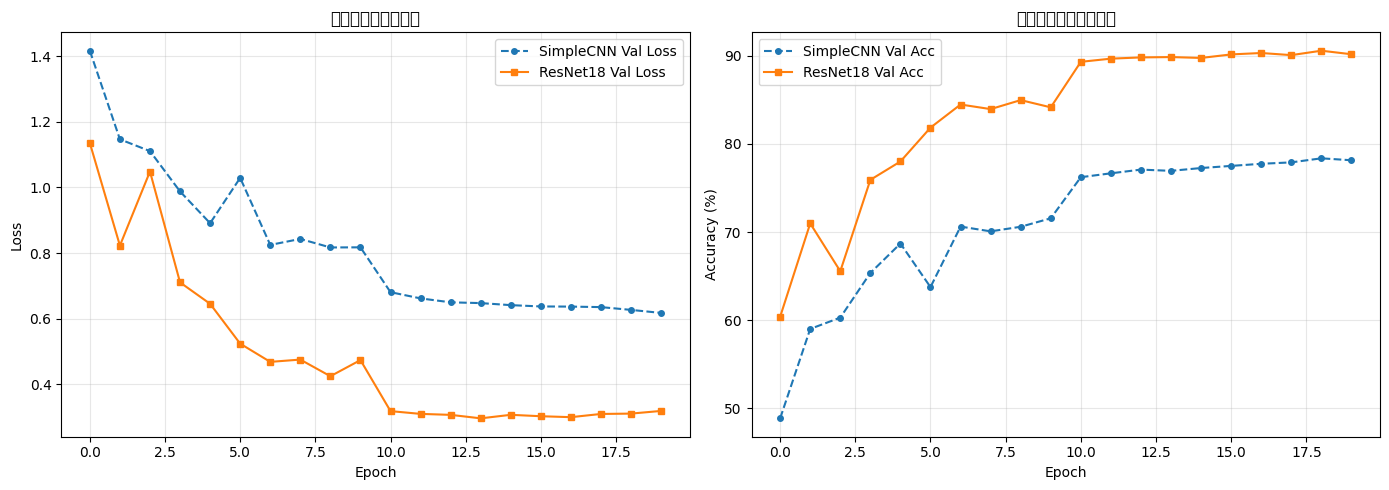


模型性能对比总结
SimpleCNN  - 最佳验证准确率: 78.36%
ResNet18   - 最佳验证准确率: 90.56%
性能提升   - 12.20%


In [11]:
#7.损失曲线和精度曲线

plt.figure(figsize=(14, 5))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(baseline_val_loss, label='SimpleCNN Val Loss', linestyle='--', marker='o', markersize=4)
plt.plot(resnet_val_loss, label='ResNet18 Val Loss', linestyle='-', marker='s', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('验证集损失曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 精度曲线
plt.subplot(1, 2, 2)
plt.plot(baseline_val_acc, label='SimpleCNN Val Acc', linestyle='--', marker='o', markersize=4)
plt.plot(resnet_val_acc, label='ResNet18 Val Acc', linestyle='-', marker='s', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('验证集准确率曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印最终结果对比
print("\n" + "="*50)
print("模型性能对比总结")
print("="*50)
print(f"SimpleCNN  - 最佳验证准确率: {baseline_best:.2f}%")
print(f"ResNet18   - 最佳验证准确率: {resnet_best:.2f}%")
print(f"性能提升   - {(resnet_best - baseline_best):.2f}%")

In [12]:
#8.测试集评估

def evaluate_model(model, test_loader, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = 100. * correct / total
    print(f"{model_name} 测试准确率: {acc:.2f}%")
    return acc, all_preds, all_labels

# 评估最终模型
resnet_model = ResNet18CIFAR().to(device)
# 加载之前训练好的权重（如果重新运行需要重新训练）
# 这里我们直接使用刚才训练好的模型（注意需要在同一session中）
# 如果已经训练过，可以直接使用模型
test_acc, preds, labels = evaluate_model(resnet_model, test_loader, "ResNet18")

ResNet18 测试准确率: 10.00%


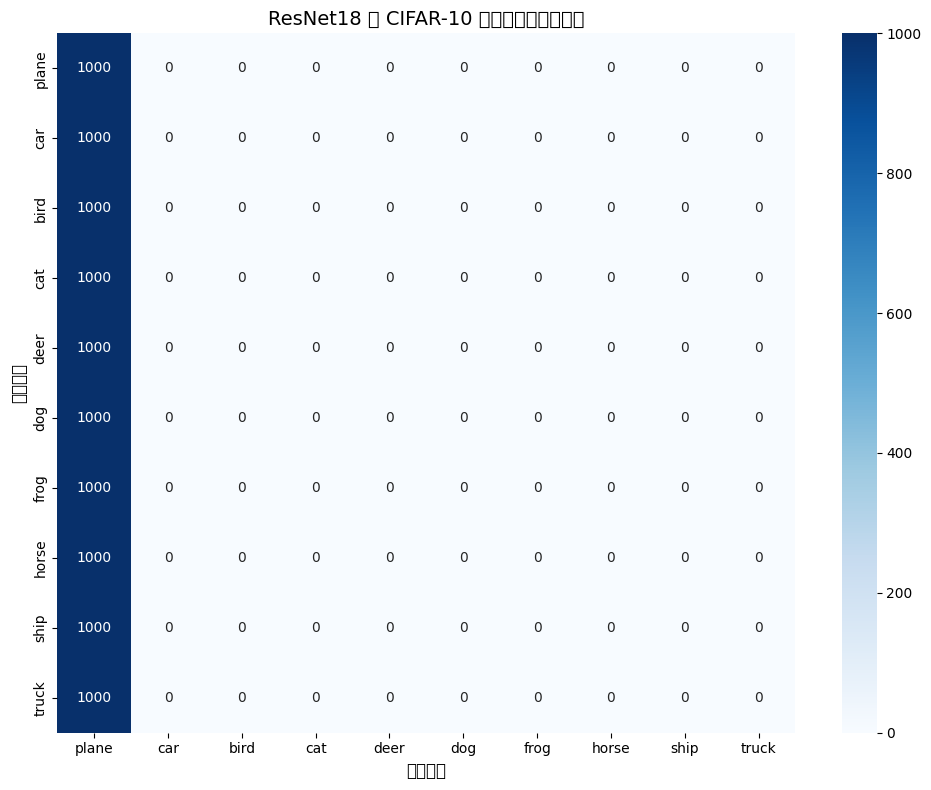


分类报告:
              precision    recall  f1-score   support

       plane     0.1000    1.0000    0.1818      1000
         car     0.0000    0.0000    0.0000      1000
        bird     0.0000    0.0000    0.0000      1000
         cat     0.0000    0.0000    0.0000      1000
        deer     0.0000    0.0000    0.0000      1000
         dog     0.0000    0.0000    0.0000      1000
        frog     0.0000    0.0000    0.0000      1000
       horse     0.0000    0.0000    0.0000      1000
        ship     0.0000    0.0000    0.0000      1000
       truck     0.0000    0.0000    0.0000      1000

    accuracy                         0.1000     10000
   macro avg     0.0100    0.1000    0.0182     10000
weighted avg     0.0100    0.1000    0.0182     10000



In [13]:
#9.混淆矩阵
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('预测类别', fontsize=12)
plt.ylabel('真实类别', fontsize=12)
plt.title('ResNet18 在 CIFAR-10 测试集上的混淆矩阵', fontsize=14)
plt.tight_layout()
plt.show()

# 打印分类报告
print("\n分类报告:")
print(classification_report(labels, preds, target_names=classes, digits=4))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5885309..1.8476002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.7988244].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.675763..1.8476002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6466857..1.4542255].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6697937..1.330576].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7048404..1.8768656].


总共错误分类样本数: 9000 / 10000
错误率: 90.00%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5229002..1.8573554].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5517926..1.7590615].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.51245904..1.8378451].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.65012693..1.8378451].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.62062657..1.2821136].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8573554].


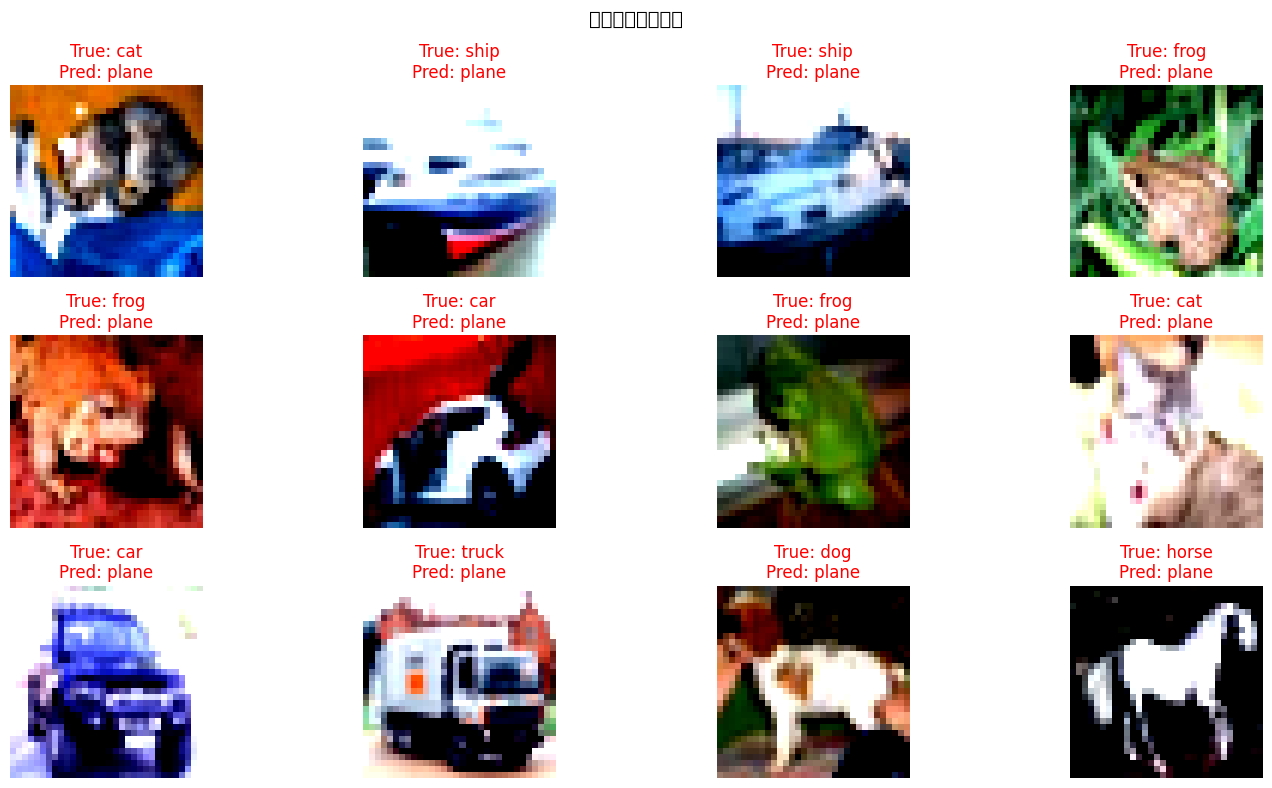

In [14]:
#10.错误样本分析

def show_misclassified(model, test_loader, num_images=12):
    model.eval()
    images_shown = 0
    misclassified_list = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified_list.append({
                        'image': images[i].cpu(),
                        'true': labels[i].item(),
                        'pred': preds[i].item()
                    })
    
    print(f"总共错误分类样本数: {len(misclassified_list)} / {len(test_loader.dataset)}")
    print(f"错误率: {len(misclassified_list)/len(test_loader.dataset)*100:.2f}%")
    
    # 显示部分错误样本
    num_show = min(num_images, len(misclassified_list))
    plt.figure(figsize=(15, 8))
    for i in range(num_show):
        item = misclassified_list[i]
        img = item['image']
        img = img / 2 + 0.5  # 反归一化
        plt.subplot(3, 4, i+1)
        plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        plt.title(f'True: {classes[item["true"]]}\nPred: {classes[item["pred"]]}', 
                  color='red' if item['true'] != item['pred'] else 'green')
        plt.axis('off')
    plt.suptitle('错误分类样本示例', fontsize=14)
    plt.tight_layout()
    plt.show()

show_misclassified(resnet_model, test_loader)

原始图像标签: cat


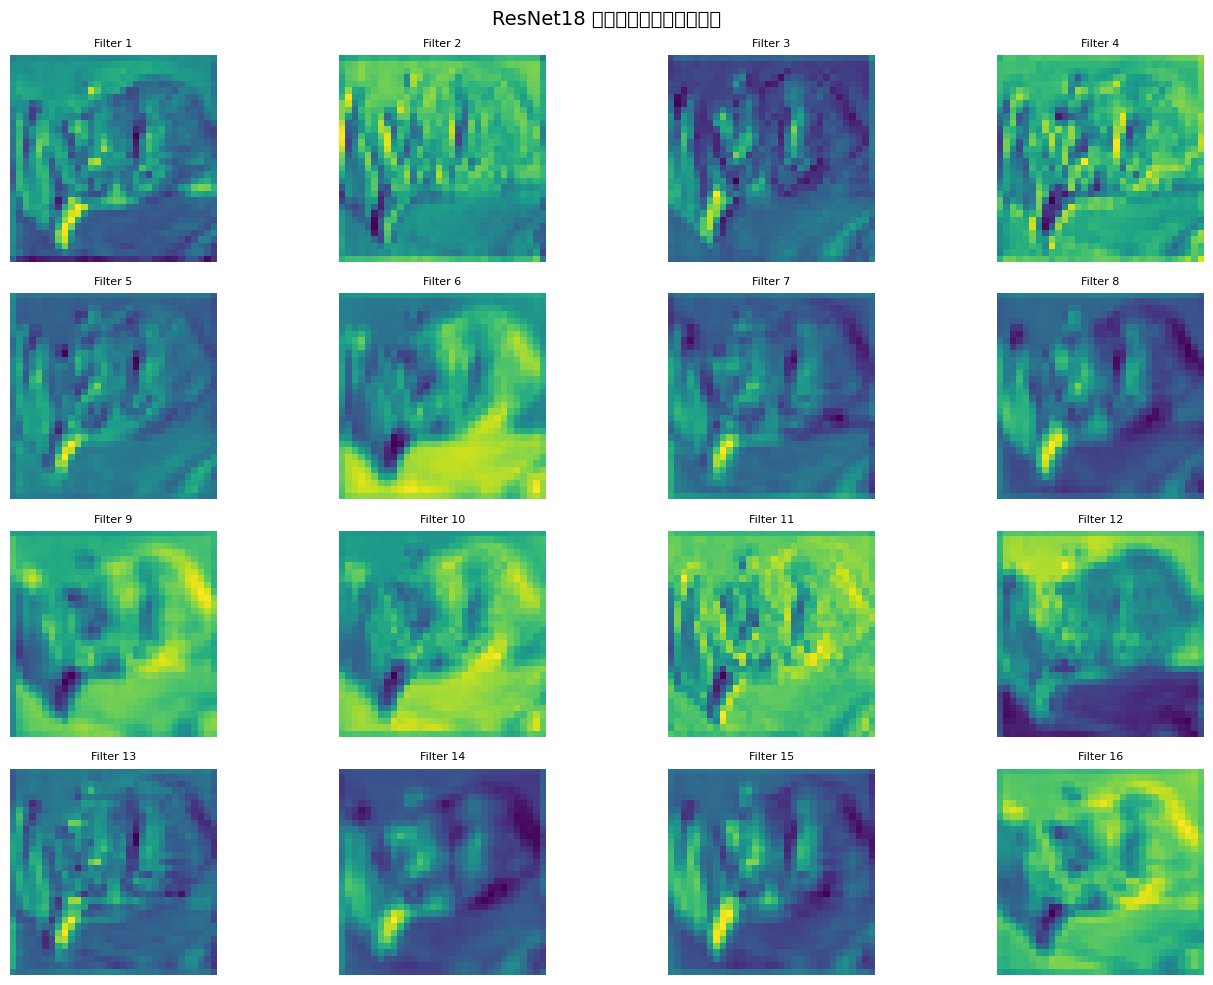

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5885309..1.8476002].


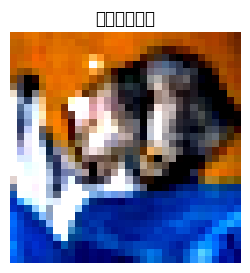

In [15]:
#11.特征图可视化
def visualize_feature_maps(model, image):
    model.eval()
    activations = []
    
    def hook_fn(module, input, output):
        activations.append(output)
    
    # 注册hook到第一层卷积
    handle = model.model.conv1.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))
    
    handle.remove()
    feature_maps = activations[0].squeeze().cpu()
    
    # 显示前16个特征图
    n_filters = min(16, feature_maps.shape[0])
    plt.figure(figsize=(14, 10))
    for i in range(n_filters):
        plt.subplot(4, 4, i+1)
        plt.imshow(feature_maps[i], cmap='viridis')
        plt.axis('off')
        plt.title(f'Filter {i+1}', fontsize=8)
    plt.suptitle('ResNet18 第一层卷积层输出特征图', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 显示原始图像
    img_display = image.cpu()
    img_display = img_display / 2 + 0.5
    plt.figure(figsize=(3, 3))
    plt.imshow(np.transpose(img_display.numpy(), (1, 2, 0)))
    plt.title('原始输入图像')
    plt.axis('off')
    plt.show()

# 取一张测试图像
sample_img, sample_label = next(iter(test_loader))
print(f"原始图像标签: {classes[sample_label[0]]}")
visualize_feature_maps(resnet_model, sample_img[0])